# BÀI THỰC HÀNH CHƯƠNG 1: XỬ LÝ ẢNH CƠ BẢN VỚI OPENCV VÀ PILLOW (PIL)

---

**Mục tiêu**:
1. Làm quen và thành thạo các thao tác cơ bản trong xử lý ảnh số sử dụng thư viện **OpenCV** và **Pillow (PIL)** trên Python.
2. Hiểu rõ sự khác biệt giữa hệ màu **BGR** (OpenCV) và **RGB** (Pillow / Matplotlib).
3. Nắm vững bản chất toán học của các không gian màu: **Grayscale**, **HSV**, và **CIE L*a*b*$.
4. Thực hành cắt xén vùng quan tâm (**ROI**), thay đổi kích thước ảnh (**Resize**) với các giải thuật nội suy khác nhau.
5. Thực hiện vẽ các đối tượng hình học cơ bản (Line, Bounding Box, Circle) và chú thích văn bản (Text Annotation) phục vụ bài toán thị giác máy tính.


## 📋 Bảng Lộ Trình Thực Thi Chuẩn Hóa (Execution Roadmap)

Bảng phân rã lộ trình triển khai từng bước kỹ thuật kèm liên kết trực tiếp tới các module mã nguồn phụ trách:

| Step | Description | What it does | Import path |
| :---: | :--- | :--- | :--- |
| **1** | **Import Libraries & Env Check** | Khởi tạo thư viện, kiểm tra phiên bản OpenCV, Pillow, NumPy và cấu hình Matplotlib inline | `—` |
| **2** | **Image I/O & Channel Handling** | Nạp ảnh BGR/RGB, phân tích siêu dữ liệu, xử lý hoán đổi kênh và lưu ảnh đa định dạng (`.png`, `.bmp`, `.jpg`) | [`src/data/transforms.py`](../../src/data/transforms.py) |
| **3** | **Color Space Conversions** | Chuyển đổi sang Grayscale (Rec. 601), HSV (tách 3 kênh H/S/V), CIE L*a*b* và vẽ lưới 2x2 | [`src/data/transforms.py`](../../src/data/transforms.py) + [`src/common/visualizer.py`](../../src/common/visualizer.py) |
| **4** | **Cropping & Resizing** | Trích xuất ROI (Pascal VOC XYXY), thay đổi kích thước theo tỷ lệ (0.5x, 1.5x) và kích thước cố định (400x300) | [`src/data/transforms.py`](../../src/data/transforms.py) + [`src/common/visualizer.py`](../../src/common/visualizer.py) |
| **5** | **Drawings & Annotations** | Vẽ đường dẫn hướng (Line), bounding box (Rectangle), tâm (Circle) và nhãn phân loại (Text) | [`src/data/transforms.py`](../../src/data/transforms.py) |
| **6** | **Pipeline Execution & Verification** | Điều phối toàn bộ luồng tự động hóa và lưu trữ 14 artifacts đầu ra | [`src/pipelines/lab01_pipeline.py`](../../src/pipelines/lab01_pipeline.py) |

---

### 🔗 Tài Liệu & Báo Cáo Kỹ Thuật Liên Quan (Documentation References)

Truy cập nhanh các tài liệu đặc tả, hướng dẫn và báo cáo chi tiết của Lab 1:
- 📄 **Báo Cáo Kỹ Thuật Chi Tiết**: [`docs/labs/lab01/LAB_01_REPORT.md`](../../docs/labs/lab01/LAB_01_REPORT.md) *(Toàn bộ Sơ đồ luồng xử lý 5 phân tầng & phân tích học thuật)*
- 🌐 **Báo Cáo Trực Quan HTML**: [`docs/labs/lab01/LAB_01_REPORT.html`](../../docs/labs/lab01/LAB_01_REPORT.html) *(Phòng trưng bày 14 visual artifacts tương tác trên trình duyệt)*
- 📋 **Đặc Tả Yêu Cầu Bài Lab**: [`docs/labs/lab01/LAB_01_DESCRIPTION.md`](../../docs/labs/lab01/LAB_01_DESCRIPTION.md) *(Nội dung đề bài và 5 yêu cầu thực hành gốc)*
- 🏠 **Tài Liệu Toàn Dự Án**: [`README.md`](../../README.md) *(Kiến trúc Clean Architecture tổng thể & quản trị workspace)*


## 1. Yêu cầu 1: Khởi tạo Môi trường & Kiểm tra Phiên bản Thư viện

Tiến hành nạp các thư viện cốt lõi và kiểm tra các thông số phiên bản:

In [14]:
import sys
from pathlib import Path
import cv2
import PIL
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Thiết lập hiển thị inline cho Matplotlib
%matplotlib inline
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["image.interpolation"] = "nearest"

print(f"Python Version  : {sys.version.split()[0]}")
print(f"OpenCV Version  : {cv2.__version__}")
print(f"Pillow Version  : {PIL.__version__}")
print(f"NumPy Version   : {np.__version__}")

Python Version  : 3.14.7
OpenCV Version  : 5.0.0
Pillow Version  : 12.3.0
NumPy Version   : 2.5.3


## 2. Yêu cầu 2: Đọc, Hiển thị và Lưu ảnh Đa định dạng

### 2.1. Đọc ảnh bằng OpenCV và Pillow
- **OpenCV (`cv2.imread`)**: Đọc ảnh dưới dạng ma trận đa chiều NumPy mảng `(H, W, C)` theo thứ tự kênh màu **BGR**.
- **Pillow (`Image.open`)**: Đọc ảnh dưới dạng đối tượng Image theo thứ tự kênh màu chuẩn **RGB**.

In [15]:
# Đường dẫn tới file ảnh mẫu thực hành
image_path = Path("../../data/samples/sample_traffic.jpg")
if not image_path.exists():
    image_path = Path("data/samples/sample_traffic.jpg")

# Đọc ảnh bằng OpenCV (BGR)
img_bgr = cv2.imread(str(image_path))
print("=== OpenCV Image Metadata ===")
print(f"Type       : {type(img_bgr)}")
print(f"Shape      : {img_bgr.shape} (Chiều cao H, Chiều rộng W, Số kênh C)")
print(f"Dtype      : {img_bgr.dtype}")
print(f"Min / Max  : [{img_bgr.min()}, {img_bgr.max()}]")

# Đọc ảnh bằng Pillow (RGB)
img_pil = Image.open(image_path)
print("\n=== Pillow Image Metadata ===")
print(f"Size       : {img_pil.size} (Chiều rộng W, Chiều cao H)")
print(f"Format     : {img_pil.format}")
print(f"Mode       : {img_pil.mode}")

=== OpenCV Image Metadata ===
Type       : <class 'numpy.ndarray'>
Shape      : (533, 800, 3) (Chiều cao H, Chiều rộng W, Số kênh C)
Dtype      : uint8
Min / Max  : [0, 247]

=== Pillow Image Metadata ===
Size       : (800, 533) (Chiều rộng W, Chiều cao H)
Format     : JPEG
Mode       : RGB


### 2.2. Hiển thị ảnh & Xử lý vấn đề hoán đổi kênh BGR <-> RGB
Khi hiển thị ảnh BGR trực tiếp trên Matplotlib, màu đỏ và màu xanh dương sẽ bị tráo đổi, tạo ra hiện tượng sai màu nghiêm trọng. Cần chuyển đổi sang RGB bằng hàm `cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)`.

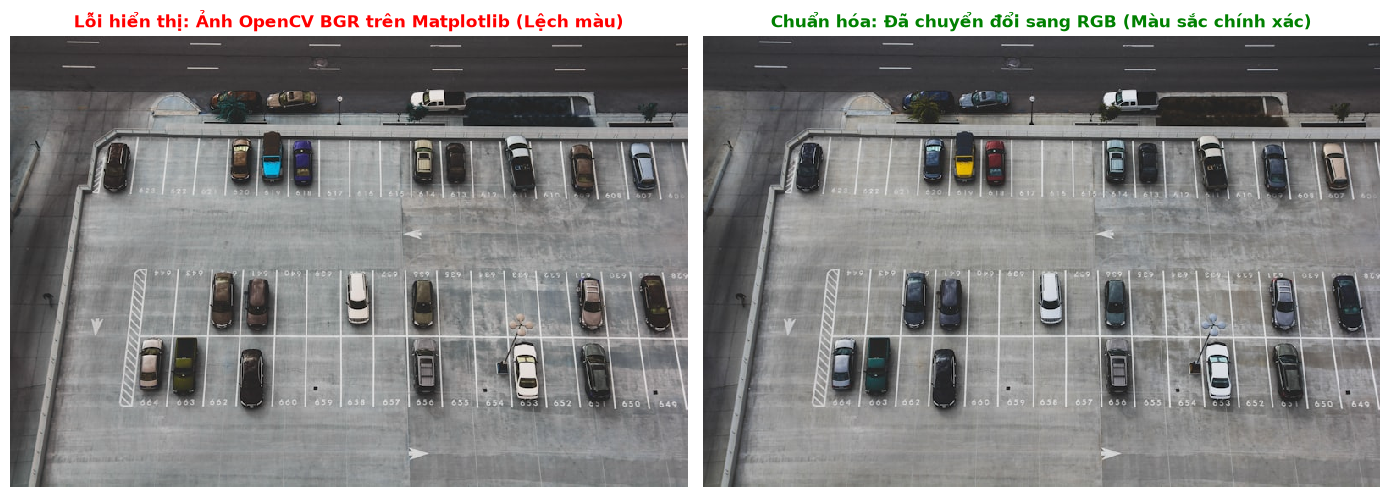

In [16]:
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Hiển thị ảnh BGR nguyên bản (Bị lệch màu trên Matplotlib)
axes[0].imshow(img_bgr)
axes[0].set_title("Lỗi hiển thị: Ảnh OpenCV BGR trên Matplotlib (Lệch màu)", color="red", fontweight="bold")
axes[0].axis("off")

# Hiển thị ảnh đã chuyển đổi sang RGB
axes[1].imshow(img_rgb)
axes[1].set_title("Chuẩn hóa: Đã chuyển đổi sang RGB (Màu sắc chính xác)", color="green", fontweight="bold")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### 2.3. Chuyển đổi và lưu ảnh sang các định dạng khác (`.png`, `.bmp`, `.jpg`)

In [17]:
out_dir = Path("../../experiments/predictions/lab01/converted")
out_dir.mkdir(parents=True, exist_ok=True)

# Lưu sang định dạng PNG (Lossless compression)
png_path = out_dir / "output.png"
cv2.imwrite(str(png_path), img_bgr)

# Lưu sang định dạng BMP (Uncompressed bitmap)
bmp_path = out_dir / "output.bmp"
cv2.imwrite(str(bmp_path), img_bgr)

# Lưu sang định dạng JPEG nén chất lượng cao (95%)
jpg_path = out_dir / "output_q95.jpg"
cv2.imwrite(str(jpg_path), img_bgr, [cv2.IMWRITE_JPEG_QUALITY, 95])

print("Dung lượng lưu trữ các định dạng:")
print(f"  - Original JPEG: {image_path.stat().st_size / 1024:.2f} KB")
print(f"  - Saved PNG    : {png_path.stat().st_size / 1024:.2f} KB")
print(f"  - Saved BMP    : {bmp_path.stat().st_size / 1024:.2f} KB")
print(f"  - Saved JPG Q95: {jpg_path.stat().st_size / 1024:.2f} KB")

Dung lượng lưu trữ các định dạng:
  - Original JPEG: 81.17 KB
  - Saved PNG    : 643.72 KB
  - Saved BMP    : 1249.27 KB
  - Saved JPG Q95: 118.98 KB


## 3. Yêu cầu 3: Chuyển đổi Không gian Màu (Color Space Conversion)

1. **Ảnh mức xám (Grayscale)**:
   Biến đổi ảnh 3 kênh sang 1 kênh độ sáng (Luminance):
   $$Y = 0.299 \cdot R + 0.587 \cdot G + 0.114 \cdot B$$
2. **Không gian màu HSV (Hue, Saturation, Value)**:
   - **Hue ($H$)**: Tông màu sắc ($0^\circ - 360^\circ$, trong OpenCV scale về $[0, 179]$).
   - **Saturation ($S$)**: Độ bão hòa/độ thuần khiết màu ($[0, 255]$).
   - **Value ($V$)**: Cường độ sáng ($[0, 255]$).
   - Ứng dụng: Nhận diện màu sắc độc lập với điều kiện chiếu sáng.
3. **Không gian màu CIE $L^*a^*b^*$**:
   - $L^*$: Độ sáng (Lightness).
   - $a^*$: Trục màu xanh lá (Green) $\leftrightarrow$ đỏ tươi (Magenta).
   - $b^*$: Trục màu xanh dương (Blue) $\leftrightarrow$ vàng (Yellow).
   - Ứng dụng: Đồng nhất cảm nhận thị giác của con người (Perceptually Uniform).

In [18]:
# Thực hiện chuyển đổi không gian màu qua OpenCV
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
img_hsv  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
img_lab  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)

print(f"Shape Grayscale : {img_gray.shape} (2 chiều: H x W)")
print(f"Shape HSV       : {img_hsv.shape} (3 chiều: H x W x 3)")
print(f"Shape LAB       : {img_lab.shape} (3 chiều: H x W x 3)")

Shape Grayscale : (533, 800) (2 chiều: H x W)
Shape HSV       : (533, 800, 3) (3 chiều: H x W x 3)
Shape LAB       : (533, 800, 3) (3 chiều: H x W x 3)


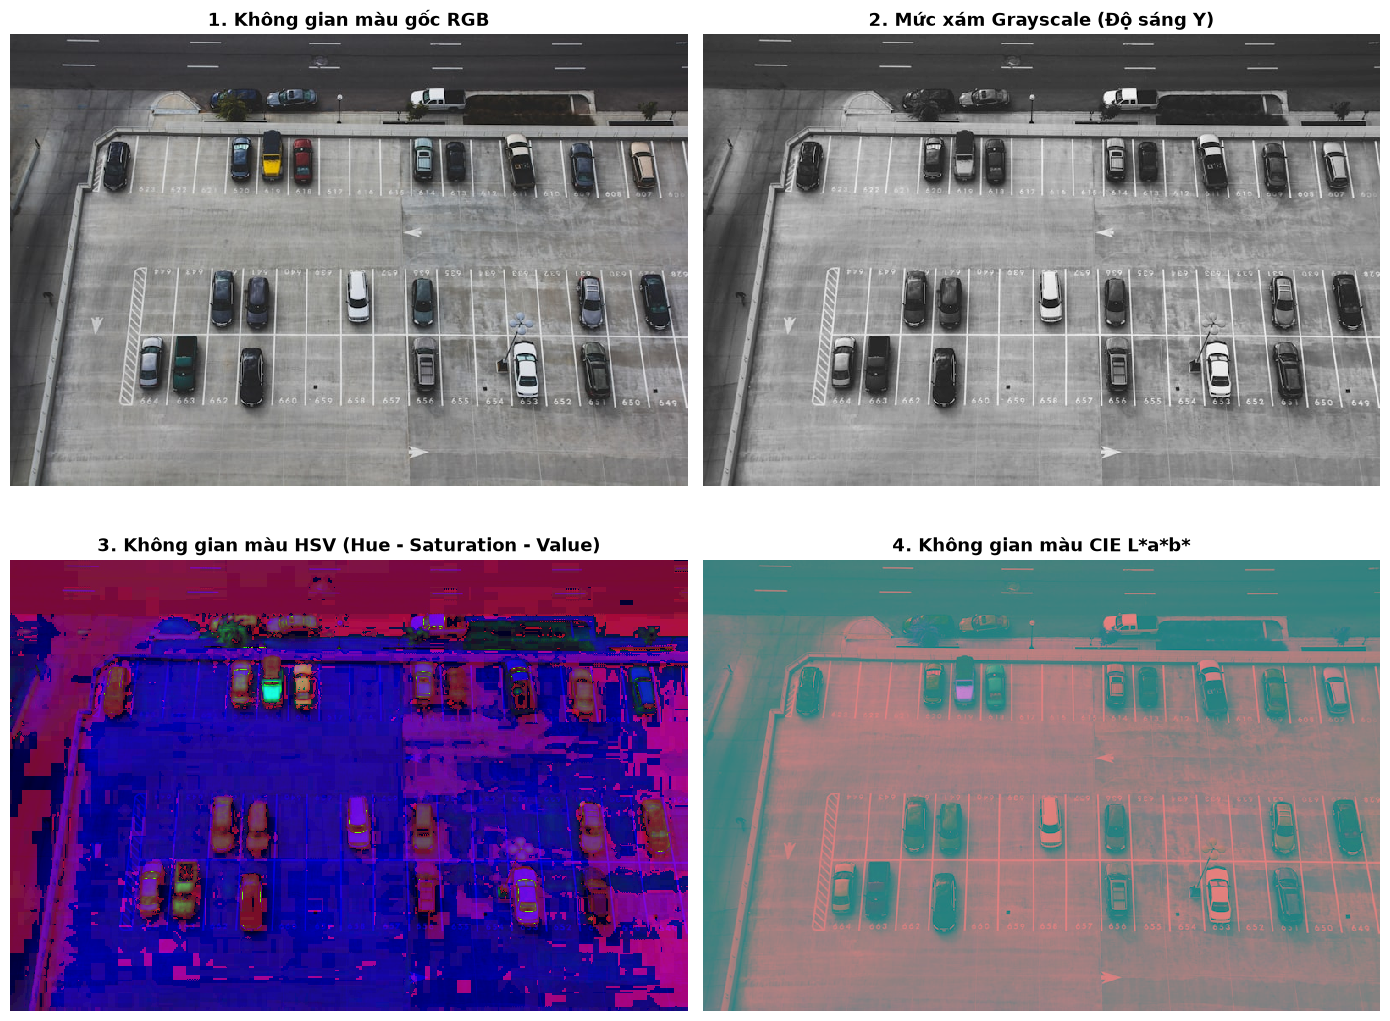

In [19]:
# Trực quan hóa so sánh 4 không gian màu trên cùng một đồ thị 2x2
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title("1. Không gian màu gốc RGB", fontsize=13, fontweight="bold")
axes[0, 0].axis("off")

axes[0, 1].imshow(img_gray, cmap="gray")
axes[0, 1].set_title("2. Mức xám Grayscale (Độ sáng Y)", fontsize=13, fontweight="bold")
axes[0, 1].axis("off")

axes[1, 0].imshow(img_hsv)
axes[1, 0].set_title("3. Không gian màu HSV (Hue - Saturation - Value)", fontsize=13, fontweight="bold")
axes[1, 0].axis("off")

axes[1, 1].imshow(img_lab)
axes[1, 1].set_title("4. Không gian màu CIE L*a*b*", fontsize=13, fontweight="bold")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

### 3.1. Phân tách và khảo sát từng kênh thành phần của HSV
Khảo sát riêng biệt 3 kênh: **H** (Sắc độ), **S** (Độ bão hòa), **V** (Cường độ sáng).

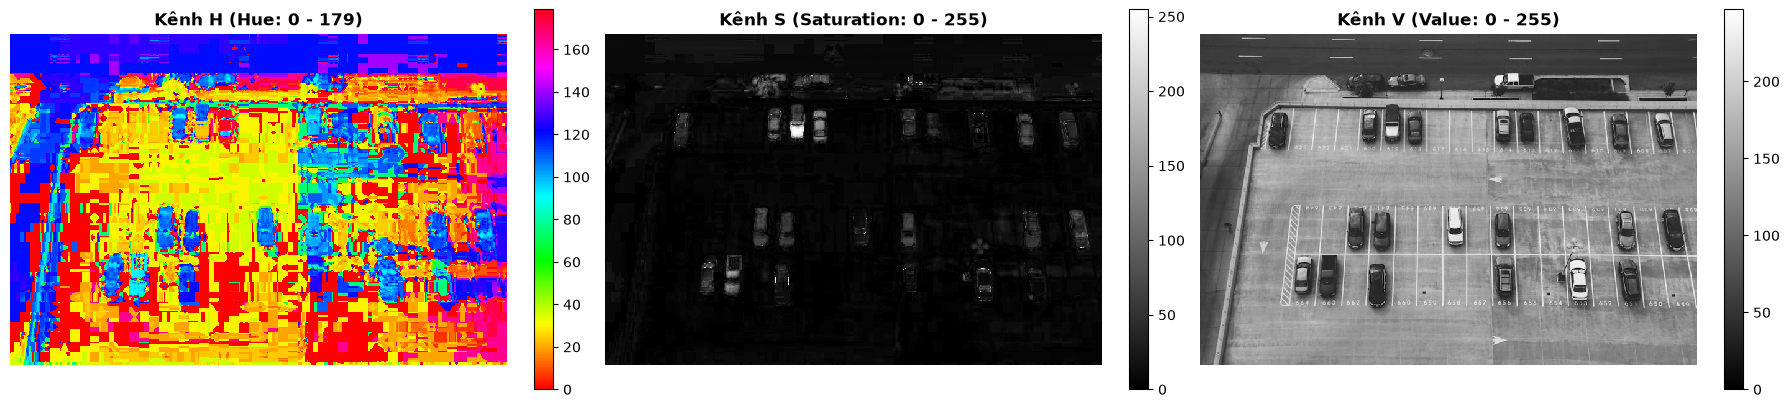

In [20]:
h, s, v = cv2.split(img_hsv)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im0 = axes[0].imshow(h, cmap="hsv")
axes[0].set_title("Kênh H (Hue: 0 - 179)", fontweight="bold")
axes[0].axis("off")
fig.colorbar(im0, ax=axes[0], fraction=0.035)

im1 = axes[1].imshow(s, cmap="gray")
axes[1].set_title("Kênh S (Saturation: 0 - 255)", fontweight="bold")
axes[1].axis("off")
fig.colorbar(im1, ax=axes[1], fraction=0.035)

im2 = axes[2].imshow(v, cmap="gray")
axes[2].set_title("Kênh V (Value: 0 - 255)", fontweight="bold")
axes[2].axis("off")
fig.colorbar(im2, ax=axes[2], fraction=0.035)

plt.tight_layout()
plt.show()

## 4. Yêu cầu 4: Cắt Xén và Thay Đổi Kích Thước (Cropping & Resizing)

### 4.1. Cắt xén vùng quan tâm (ROI - Region of Interest)
- Trên NumPy, ảnh là mảng `[H, W, C]`. Do đó việc cắt ROI được thực hiện qua kỹ thuật cắt lát (Slicing): `image[y1:y2, x1:x2]`.
- Tọa độ hộp bao chuẩn Pascal VOC: `(x1, y1)` là góc trên-trái, `(x2, y2)` là góc dưới-phải.

Kích thước ảnh gốc: (533, 800, 3)
Tọa độ ROI        : [x1=200, y1=186, x2=600, y2=453]
Kích thước ROI    : (267, 400, 3)


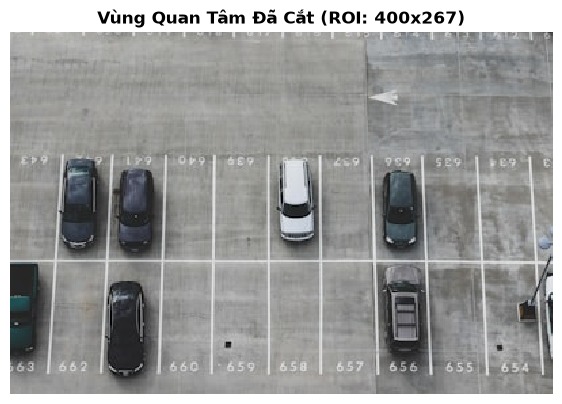

In [21]:
h_orig, w_orig = img_bgr.shape[:2]

# Trích xuất ROI trung tâm
x1, y1 = int(w_orig * 0.25), int(h_orig * 0.35)
x2, y2 = int(w_orig * 0.75), int(h_orig * 0.85)

img_roi = img_bgr[y1:y2, x1:x2].copy()
print(f"Kích thước ảnh gốc: {img_bgr.shape}")
print(f"Tọa độ ROI        : [x1={x1}, y1={y1}, x2={x2}, y2={y2}]")
print(f"Kích thước ROI    : {img_roi.shape}")

plt.figure(figsize=(7, 5))
plt.imshow(cv2.cvtColor(img_roi, cv2.COLOR_BGR2RGB))
plt.title(f"Vùng Quan Tâm Đã Cắt (ROI: {img_roi.shape[1]}x{img_roi.shape[0]})", fontweight="bold")
plt.axis("off")
plt.show()

### 4.2. Thay đổi kích thước (Resize)
- **Theo tỷ lệ phần trăm (Scale factor)**: `cv2.resize(image, (0, 0), fx=0.5, fy=0.5)`.
- **Theo kích thước cố định (Width x Height)**: `cv2.resize(image, (target_w, target_h))`.
- *Lưu ý*: Đối với thu nhỏ ảnh nên ưu tiên `INTER_AREA`, đối với phóng to nên ưu tiên `INTER_CUBIC` hoặc `INTER_LINEAR`.

In [22]:
# 1. Thu nhỏ 50% theo tỷ lệ
img_half = cv2.resize(img_bgr, (0, 0), fx=0.5, fy=0.5, interpolation=cv2.INTER_AREA)

# 2. Phóng to 150% theo tỷ lệ
img_upscaled = cv2.resize(img_bgr, (0, 0), fx=1.5, fy=1.5, interpolation=cv2.INTER_CUBIC)

# 3. Đổi về kích thước cố định 400x300 pixel
target_w, target_h = 400, 300
img_fixed = cv2.resize(img_bgr, (target_w, target_h), interpolation=cv2.INTER_LINEAR)

print(f"Kích thước ban đầu     : {img_bgr.shape[1]} x {img_bgr.shape[0]}")
print(f"Kích thước thu nhỏ 0.5x: {img_half.shape[1]} x {img_half.shape[0]}")
print(f"Kích thước phóng to 1.5x: {img_upscaled.shape[1]} x {img_upscaled.shape[0]}")
print(f"Kích thước cố định      : {img_fixed.shape[1]} x {img_fixed.shape[0]}")

Kích thước ban đầu     : 800 x 533
Kích thước thu nhỏ 0.5x: 400 x 266
Kích thước phóng to 1.5x: 1200 x 800
Kích thước cố định      : 400 x 300


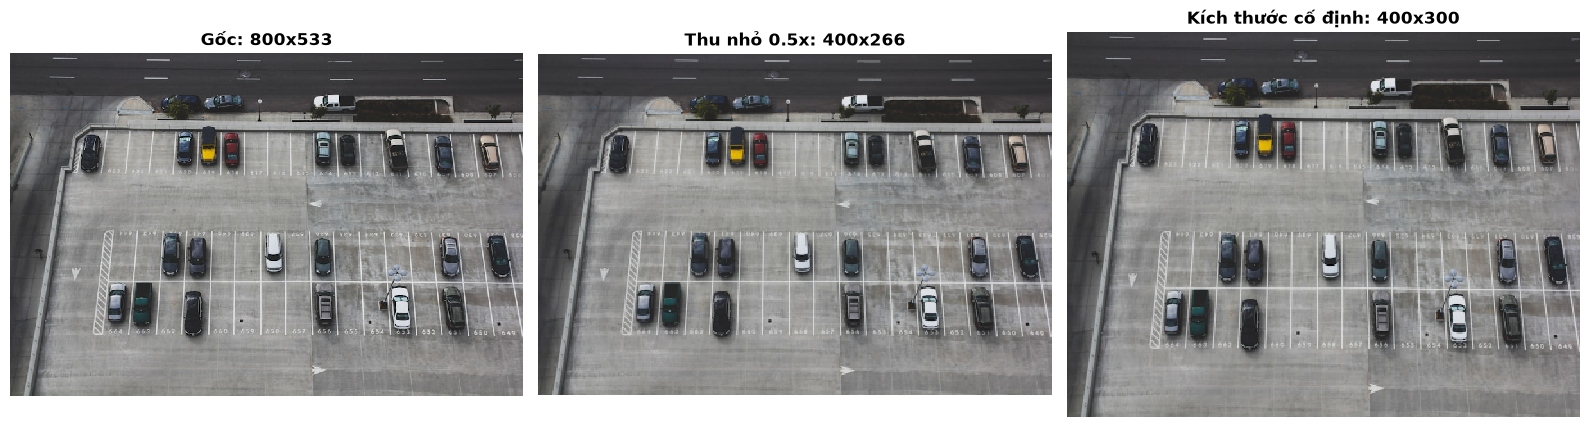

In [23]:
# So sánh trực quan
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Gốc: {img_bgr.shape[1]}x{img_bgr.shape[0]}", fontweight="bold")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(img_half, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Thu nhỏ 0.5x: {img_half.shape[1]}x{img_half.shape[0]}", fontweight="bold")
axes[1].axis("off")

axes[2].imshow(cv2.cvtColor(img_fixed, cv2.COLOR_BGR2RGB))
axes[2].set_title(f"Kích thước cố định: {target_w}x{target_h}", fontweight="bold")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## 5. Yêu cầu 5: Vẽ Hình Cơ Bản và Chèn Văn Bản Chú Thích (Drawing & Annotations)

Trong các bài toán thị giác máy tính như Nhận diện vật thể (Object Detection) và Theo dõi chuyển động (Tracking), việc vẽ bounding box, tâm vật thể (centroid), làn đường (lanes) và nhãn phân loại (labels) là thao tác thường xuyên và bắt buộc:
1. **`cv2.line`**: Vẽ đường thẳng/làn đường.
2. **`cv2.rectangle`**: Vẽ khung bao nhận diện (Bounding box).
3. **`cv2.circle`**: Đánh dấu tâm đối tượng hoặc điểm đặc trưng.
4. **`cv2.putText`**: Chèn thông tin nhãn lớp, độ tin cậy (Confidence score).

In [24]:
# Tạo bản sao ảnh để không làm thay đổi dữ liệu gốc
canvas = img_bgr.copy()

# 1. Vẽ đường thẳng (Line) đại diện cho vạch hướng dẫn giao thông (Màu xanh lá - BGR: [0, 255, 0])
cv2.line(
    canvas,
    pt1=(int(w_orig * 0.05), int(h_orig * 0.92)),
    pt2=(int(w_orig * 0.95), int(h_orig * 0.92)),
    color=(0, 255, 0),
    thickness=3,
    lineType=cv2.LINE_AA
)

# 2. Vẽ hình chữ nhật (Bounding Box) quanh vùng ROI mục tiêu (Màu đỏ - BGR: [0, 0, 255])
cv2.rectangle(
    canvas,
    pt1=(x1, y1),
    pt2=(x2, y2),
    color=(0, 0, 255),
    thickness=3,
    lineType=cv2.LINE_AA
)

# 3. Vẽ hình tròn (Circle) đánh dấu tâm (Centroid) của xe/vật thể (Màu cam - BGR: [0, 165, 255])
cx, cy = (x1 + x2) // 2, (y1 + y2) // 2
cv2.circle(
    canvas,
    center=(cx, cy),
    radius=20,
    color=(0, 165, 255),
    thickness=3,
    lineType=cv2.LINE_AA
)
cv2.circle(canvas, center=(cx, cy), radius=4, color=(0, 0, 255), thickness=-1) # Điểm tâm đặc

# 4. Chèn văn bản (Text / Annotation) với phông FONT_HERSHEY_SIMPLEX
# Nền nhãn (Label background banner)
label_text = "Vehicle ROI: 98.5%"
font = cv2.FONT_HERSHEY_SIMPLEX
font_scale = 0.75
thickness = 2
(txt_w, txt_h), baseline = cv2.getTextSize(label_text, font, font_scale, thickness)

cv2.rectangle(canvas, (x1, y1 - txt_h - 10), (x1 + txt_w + 10, y1), (0, 0, 255), -1) # Banner nền đỏ
cv2.putText(
    canvas,
    text=label_text,
    org=(x1 + 5, y1 - 5),
    fontFace=font,
    fontScale=font_scale,
    color=(255, 255, 255),
    thickness=thickness,
    lineType=cv2.LINE_AA
)

# Chú thích thương hiệu UTH
cv2.putText(
    canvas,
    text="UTH AI & Computer Vision Lab 1",
    org=(20, 40),
    fontFace=cv2.FONT_HERSHEY_DUPLEX,
    fontScale=0.8,
    color=(0, 255, 255),
    thickness=2,
    lineType=cv2.LINE_AA
)

array([[[ 59,  57,  57],
        [ 59,  57,  57],
        [ 58,  56,  56],
        ...,
        [ 49,  49,  49],
        [ 49,  49,  49],
        [ 49,  49,  49]],

       [[ 59,  57,  57],
        [ 59,  57,  57],
        [ 59,  57,  57],
        ...,
        [ 50,  50,  50],
        [ 49,  49,  49],
        [ 49,  49,  49]],

       [[ 60,  58,  58],
        [ 59,  57,  57],
        [ 59,  57,  57],
        ...,
        [ 52,  50,  50],
        [ 52,  50,  50],
        [ 52,  50,  50]],

       ...,

       [[ 72,  77,  76],
        [ 67,  72,  71],
        [ 71,  76,  75],
        ...,
        [132, 134, 135],
        [132, 134, 134],
        [132, 134, 134]],

       [[ 70,  75,  74],
        [ 67,  72,  71],
        [ 71,  76,  75],
        ...,
        [131, 133, 134],
        [132, 134, 134],
        [132, 134, 134]],

       [[ 69,  74,  73],
        [ 68,  73,  72],
        [ 73,  78,  77],
        ...,
        [128, 132, 133],
        [129, 134, 133],
        [129, 134, 133]]

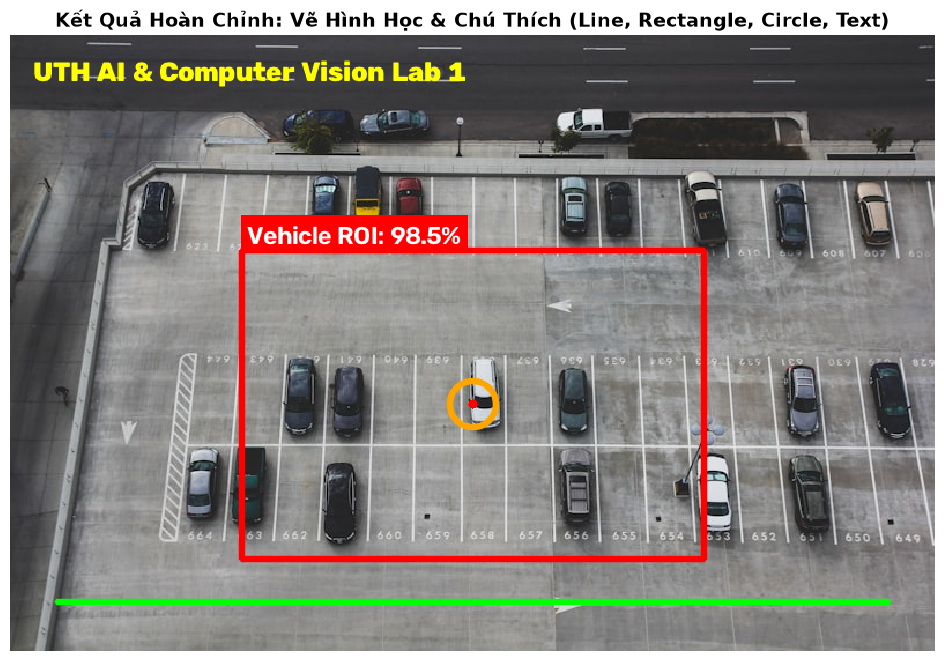

In [25]:
# Hiển thị ảnh sau khi vẽ và chú thích
plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
plt.title("Kết Quả Hoàn Chỉnh: Vẽ Hình Học & Chú Thích (Line, Rectangle, Circle, Text)", fontsize=14, fontweight="bold")
plt.axis("off")
plt.show()

## 6. Tổng Kết và So Sánh Giữa OpenCV và Pillow

| Tiêu chí | OpenCV (`cv2`) | Pillow (`PIL`) |
| :--- | :--- | :--- |
| **Cấu trúc lưu trữ dữ liệu** | Mảng NumPy `np.ndarray` đa chiều | Đối tượng `PIL.Image.Image` chuyên dụng |
| **Kênh màu mặc định** | **BGR** (Blue, Green, Red) | **RGB** (Red, Green, Blue) |
| **Đại diện kích thước** | `(Height, Width, Channels)` | `(Width, Height)` |
| **Hiệu năng & Tốc độ** | Rất cao (tối ưu hóa bằng C/C++, SSE, AVX, GPU) | Trung bình (tối ưu cho các tác vụ đồ họa và định dạng cơ bản) |
| **Hệ sinh thái xử lý ảnh** | Cực kỳ mạnh mẽ: Edge detection, Filtering, Morphological, Deep Learning | Rất tốt cho tác vụ xoay, paste, watermark, lưu các định dạng GIF/TIFF |
| **Khả năng tương thích DL** | Tích hợp trực tiếp với PyTorch (`torch.from_numpy`) | Tích hợp chuẩn qua `torchvision.transforms` |
